# Small crystalline dataset

> Georgios Varnavides | Oct 21 2025  
>
> Sample: thin strontium titanate (STO)  
> Sampling conditions: Nyquist  
> Imaging conditions: 20 mrad, in-focus, defocus, coma, defocus + coma  

In [1]:
import abtem
import ase
import numpy as np
import matplotlib.pyplot as plt

## STO Unitcell

We'll make an ASE Atoms object using Materials Project entry [mp-5229](https://next-gen.materialsproject.org/materials/mp-5229). Note this uses Wyckoff Positions and Spacegroups, but you can also export the CIF/POSCAR file if you prefer.

In [2]:
spacegroup = ase.spacegroup.Spacegroup("Pm-3m") # 221
lattice_parameter = 3.91 # Angstroms

wyckoff_symbols = np.array(['Sr', 'Ti', 'O'])
# from Materials Project
scaled_positions, kinds = spacegroup.equivalent_sites(
    scaled_positions=[
        (0, 0, 0),       # Sr at 1a
        (0.5, 0.5, 0.5), # Ti at 1b
        (0.5, 0, 0.5)    # O at 3c (one of the three equivalent positions)
    ]
)

sto_unitcell = ase.Atoms(
    symbols = wyckoff_symbols[kinds],
    scaled_positions = scaled_positions,
    cell=[lattice_parameter, lattice_parameter, lattice_parameter],
    pbc=True
)

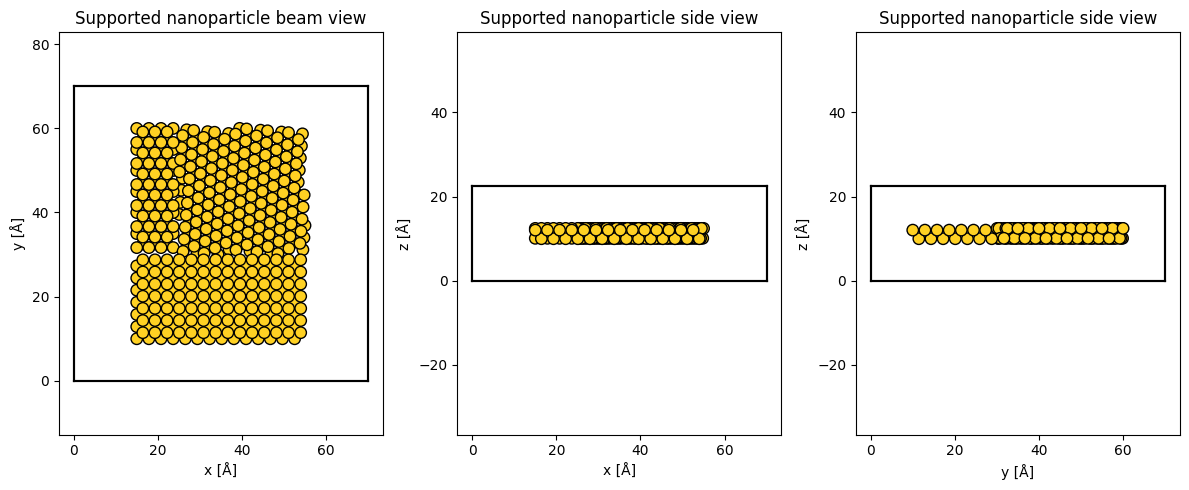

In [8]:
from ase.build import fcc111, fcc100
lc=4.08
unit_cell = fcc111('Au', size=(2, 2, 2), a=lc, vacuum=0.1, orthogonal=False)
unit_cell_3 = fcc100('Au', size=(2, 2, 2), a=lc, vacuum=0.00001)
nanoparticle_1 = abtem.orthogonalize_cell(unit_cell) * (16,8,1)
nanoparticle_2 = abtem.orthogonalize_cell(unit_cell) * (16,8,1)
nanoparticle_3 = abtem.orthogonalize_cell(unit_cell_3) * (16,8,1)
nanoparticle_2.rotate(25,'z')
# Get positions for each nanoparticle
pos1 = nanoparticle_1.get_positions()
pos2 = nanoparticle_2.get_positions()
pos3 = nanoparticle_3.get_positions()

# Create boolean masks based on x, y conditions
mask1 = (pos1[:, 0] < 10) & (pos1[:, 1] > 20) & (pos1[:, 1] <50)  # x < 10 AND y < 15
mask2 = (pos2[:, 0] > 10) & (pos2[:, 1] > 20) & (pos2[:, 1] <50) & (pos2[:,0] <40) # x > 10 AND y > 15
mask3 = (pos3[:, 1] < 20) & (pos3[:,0] <40)

# Apply masks using index arrays
filtered_1 = nanoparticle_1[np.where(mask1)[0]]
filtered_2 = nanoparticle_2[np.where(mask2)[0]]
filtered_3 = nanoparticle_3[np.where(mask3)[0]]

# Combine the two filtered structures
supported_nanoparticle = filtered_1 + filtered_2 + filtered_3
supported_nanoparticle.center(vacuum=10)
x_length = supported_nanoparticle.cell[0, 0]
y_length = supported_nanoparticle.cell[1, 1]
max_length = max(x_length, y_length)

if x_length < max_length:
    extra_vacuum = (max_length - x_length) / 2
    supported_nanoparticle.center(axis=0, vacuum=10 + extra_vacuum)

if y_length < max_length:
    extra_vacuum = (max_length - y_length) / 2
    supported_nanoparticle.center(axis=1, vacuum=10 + extra_vacuum)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    supported_nanoparticle,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.5,
    scale=1,
)
abtem.show_atoms(
    supported_nanoparticle,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)
abtem.show_atoms(
    supported_nanoparticle,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)
fig.tight_layout();

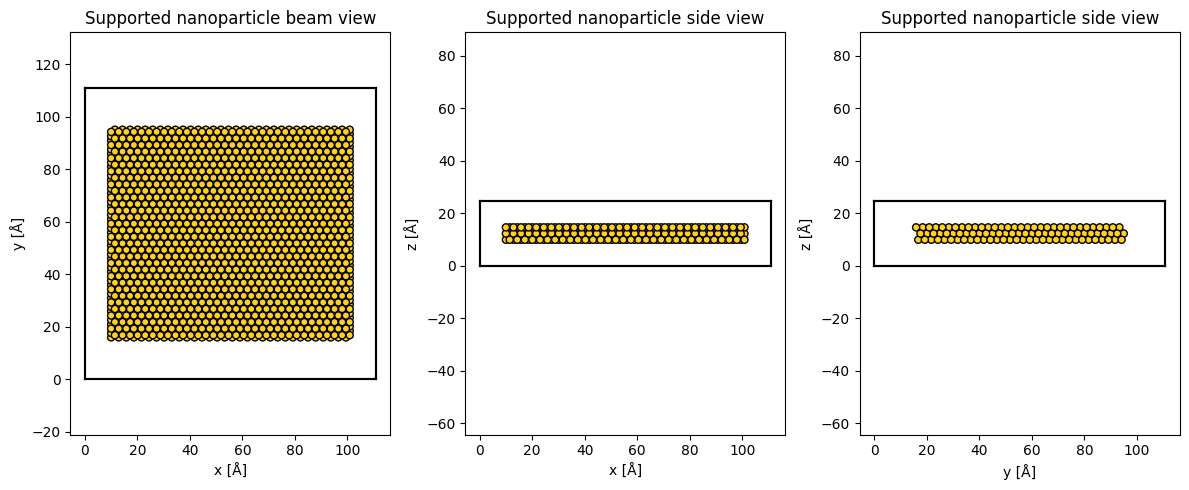

In [4]:
from ase.build import fcc111, fcc100
lc=4.08
unit_cell = fcc111('Au', size=(2, 2, 3), a=lc, vacuum=0.1, orthogonal=False)
nanoparticle_1 = abtem.orthogonalize_cell(unit_cell) * (16,8,1)
# Get positions for each nanoparticle
pos1 = nanoparticle_1.get_positions()




# Combine the two filtered structures
supported_nanoparticle = nanoparticle_1
supported_nanoparticle.center(vacuum=10)
x_length = supported_nanoparticle.cell[0, 0]
y_length = supported_nanoparticle.cell[1, 1]
max_length = max(x_length, y_length)

if x_length < max_length:
    extra_vacuum = (max_length - x_length) / 2
    supported_nanoparticle.center(axis=0, vacuum=10 + extra_vacuum)

if y_length < max_length:
    extra_vacuum = (max_length - y_length) / 2
    supported_nanoparticle.center(axis=1, vacuum=10 + extra_vacuum)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    supported_nanoparticle,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.5,
    scale=1,
)
abtem.show_atoms(
    supported_nanoparticle,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)
abtem.show_atoms(
    supported_nanoparticle,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)
fig.tight_layout();

## STO Atoms

We'll tile the unitcell 6 times in the in-plane direction, and 3 times along the beam direction.

_Note:_ This is unrealistically thin, and we'll use it to investigate weak-phase imaging techniques. More realistic thicker specimens will be investigated with a different dataset.

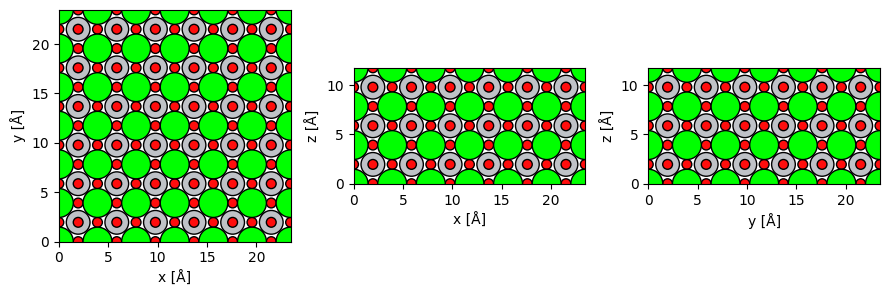

In [9]:
repetitions = (6,6,3)
sto_atoms = sto_unitcell * repetitions

fig, axs = plt.subplots(1,3,figsize=(3*3,3*1))
for ax, plane in zip(axs,['xy','xz','yz']):
    abtem.show_atoms(
        sto_atoms,ax=ax,plane=plane,
        tight_limits=True,
        show_periodic=True,
    )
fig.tight_layout()

## Potential 

We build the numeric representation of the atomic potentials.

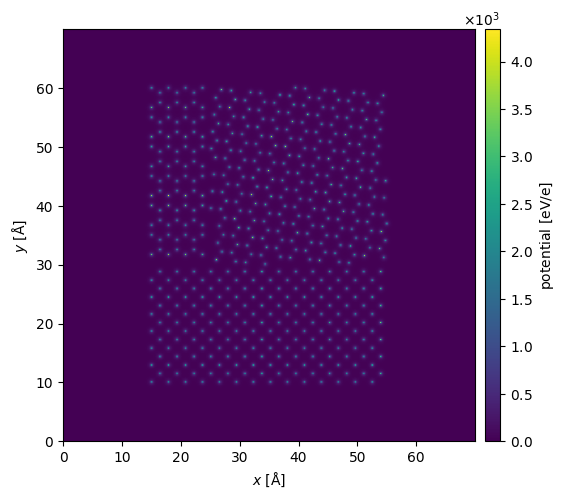

In [10]:
potential = abtem.Potential(
    supported_nanoparticle,
    sampling=lattice_parameter/64,
    slice_thickness= lattice_parameter/8,
).build(
    lazy=False
)

potential.show(
    cbar=True
);

## Probe

We use a converged probe with a few different aberrations.

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

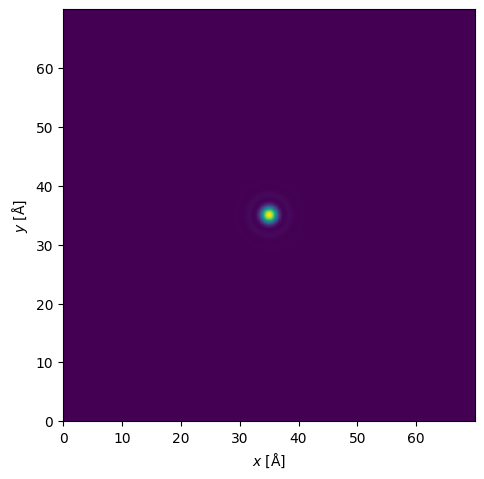

In [11]:
energy = 20e3 # eV
semiangle_cutoff = 20 # mrad

middle_focus_offset = supported_nanoparticle.cell[2,2]/2
defocus_magnitude= 50
coma_magnitude = 0

aberrations = {
    "C10":defocus_magnitude,
    "C21":coma_magnitude,
    "phi21":-0.8,
}

# 2x2 probes ensemble
probes = abtem.Probe(
    energy=energy,
    semiangle_cutoff=semiangle_cutoff,
    aberrations=aberrations,
).match_grid(
    potential
)

probes.show(
    explode=True
)

## Simulations

In [12]:
grid_scan_Nyquist = abtem.GridScan(
    start = (0, 0),
    end = (potential.extent[0], potential.extent[1]),
    gpts=(48,48)
)

detector = abtem.PixelatedDetector(
    max_angle=None
)

In [13]:
measurements = probes.scan(
    potential,
    grid_scan_Nyquist,
    detector
).compute(
).crop(
    gpts=(192,192)
)

tasks:   0%|          | 0/194 [00:00<?, ?it/s]

## Save Multidimensional Dataset
Temporary fix, until abTEM supports zarr>3.

In [14]:
import quantem as em

sampling = [
    grid_scan_Nyquist.sampling[0],
    grid_scan_Nyquist.sampling[1],
    measurements.angular_sampling[0],
    measurements.angular_sampling[1],
]

units = ["A","A","mrad","mrad"]
# units = ["A","A","A^-1","A^-1"]


dataset = em.core.datastructures.Dataset.from_array(
    measurements.to_cpu().array,
    sampling=sampling,
    units=units,
)

dataset.save("/home/wdekleijne/git-repos/willem-playground/data/gold_20mrad_C10_C21_Nyquist_plane_3_layer_fcc.zip",mode='o')

In [15]:
def add_poisson_noise(
    dataset,
    electrons_per_area,
):
    if electrons_per_area == np.inf:
        return dataset
    electrons_per_probe = electrons_per_area * dataset.sampling[:2].prod()
    
    dataset_noisy = dataset.copy()
    dataset_noisy.array = np.random.poisson(dataset.array * electrons_per_probe)
    return dataset_noisy

In [16]:
dose = 10e6
noisy_dataset = add_poisson_noise(
            dataset,
            dose
        )
noisy_dataset.save(f"/home/wdekleijne/git-repos/willem-playground/data/gold_20mrad_C10_C21_{dose:.0e}-dose_Nyquist_plane_3_layer_fcc.zip",mode='o')